In [11]:
from google.colab import files
uploaded = files.upload()

Saving banknote_authentication.csv to banknote_authentication (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Global plot settings
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15

In [ ]:
df = pd.read_csv("banknote_authentication.csv")

In [ ]:
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
print(df.columns)

Index(['variance', 'skewness', 'curtosis', 'entropy', 'class'], dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
print(df.shape)

(1372, 5)


In [ ]:
print(df.isnull().sum())

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


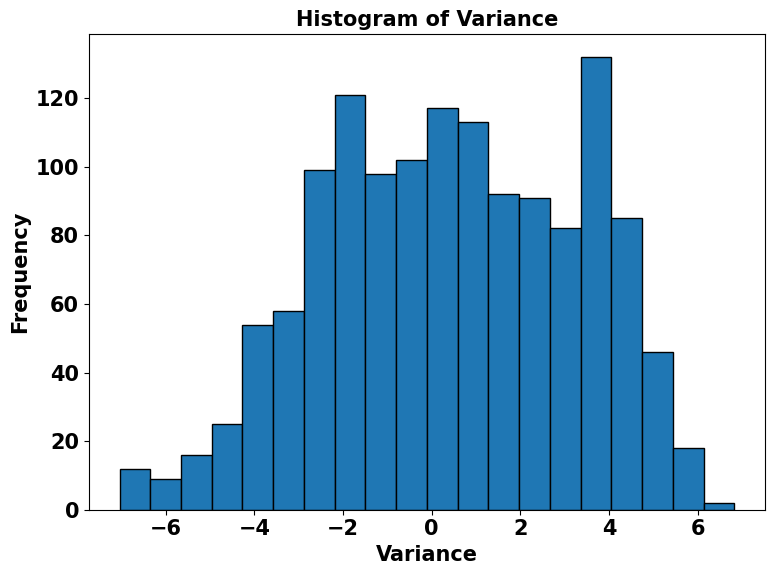

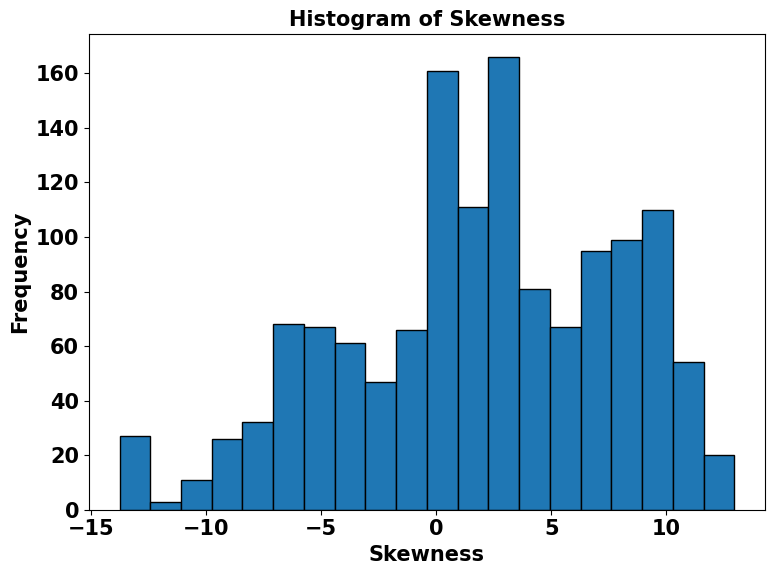

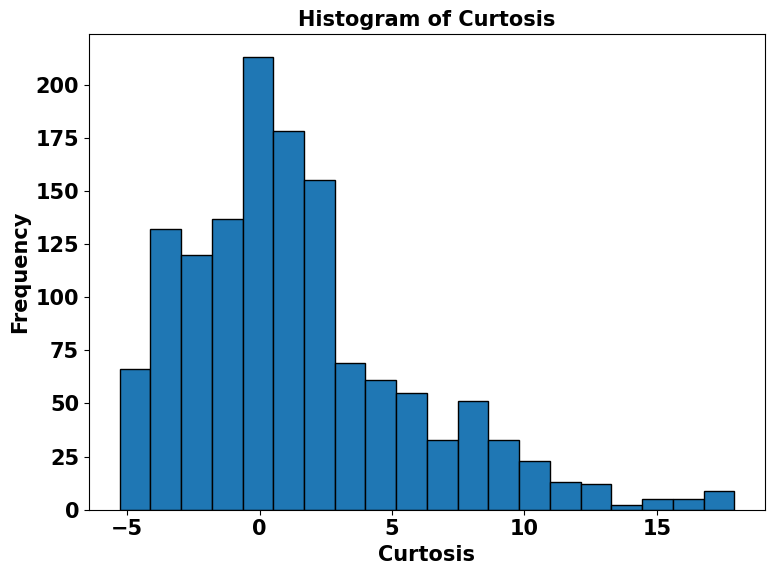

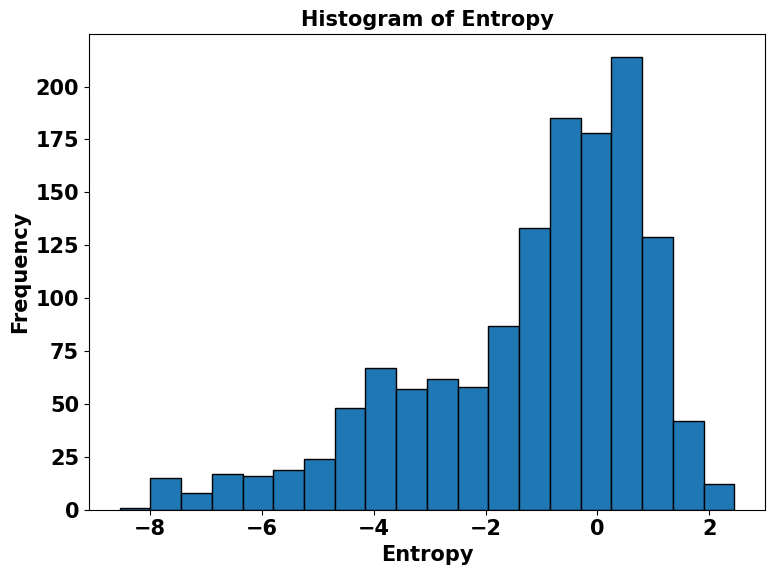

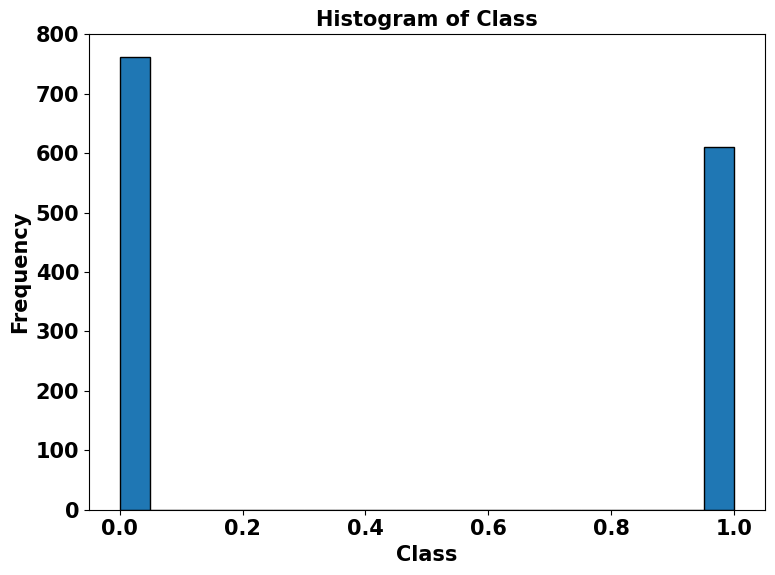

In [ ]:

for col in df.columns:
  plt.figure(figsize=(8,6))

  plt.hist(df[col], bins=20, edgecolor='black')

  plt.xlabel(col.title(), fontsize=15, fontweight='bold')
  plt.ylabel("Frequency", fontsize=15, fontweight='bold')
  plt.title(f"Histogram of {col.title()}", fontsize=15, fontweight='bold')

  plt.tight_layout()

  plt.savefig(f"Histogram_{col}.eps",
              format='eps',
              dpi=600,
              bbox_inches='tight')

  plt.show()

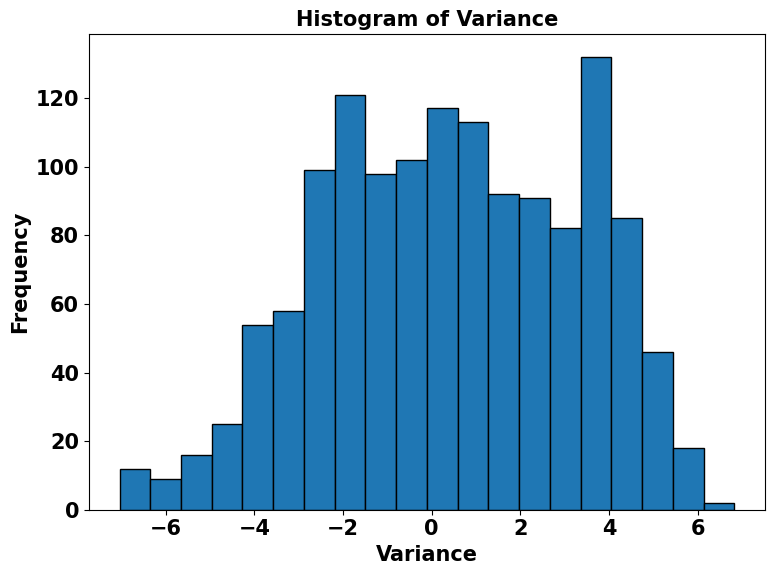

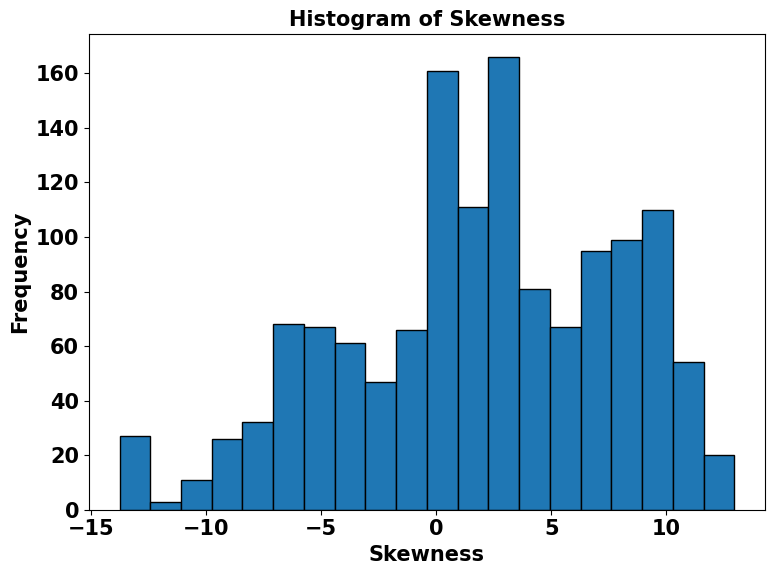

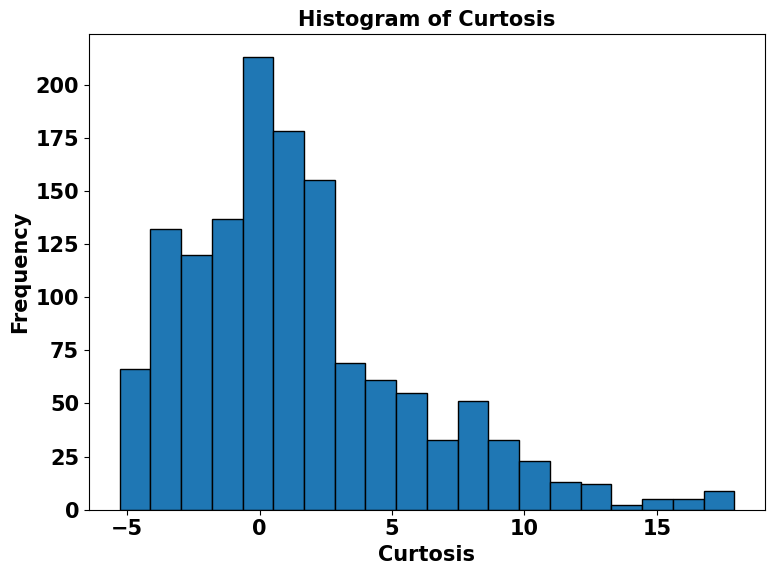

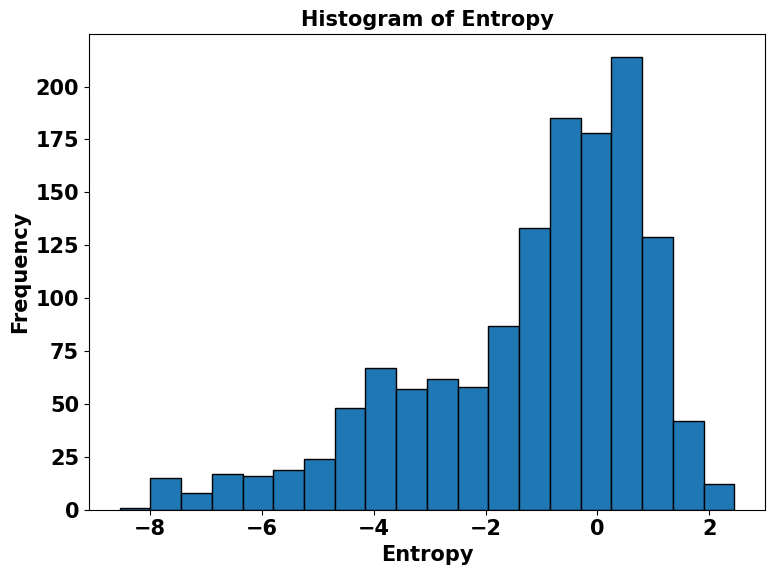

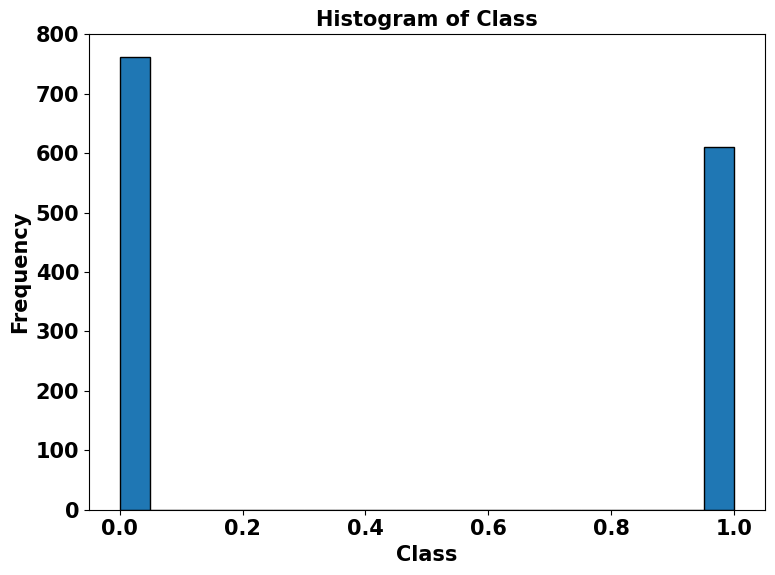

In [12]:
for col in df.columns:
  plt.figure(figsize=(8,6))

  plt.hist(df[col], bins=20, edgecolor='black')

  plt.xlabel(col.title(), fontsize=15, fontweight='bold')
  plt.ylabel("Frequency", fontsize=15, fontweight='bold')
  plt.title(f"Histogram of {col.title()}", fontsize=15, fontweight='bold')

  plt.tight_layout()

  plt.savefig(f"Histogram_{col}.eps",
              format='eps',
              dpi=600,
              bbox_inches='tight')

  plt.show()

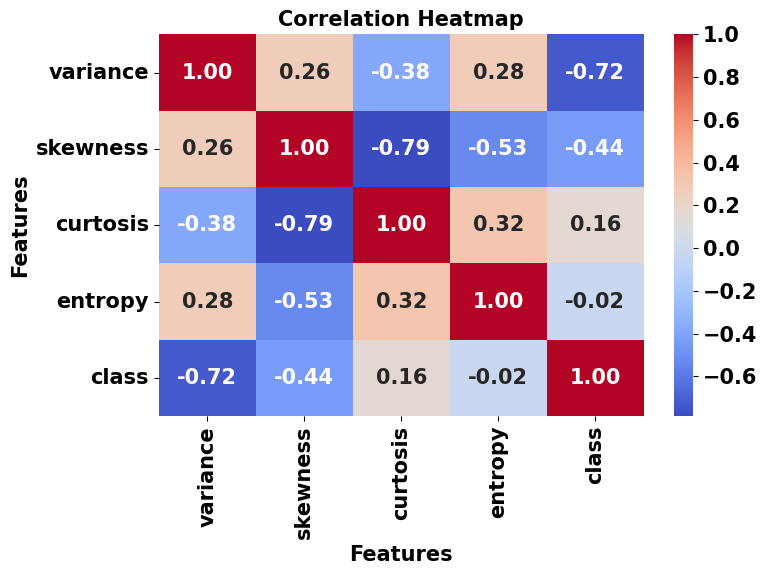

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.xlabel("Features", fontsize=15, fontweight='bold')
plt.ylabel("Features", fontsize=15, fontweight='bold')
plt.title("Correlation Heatmap", fontsize=15, fontweight='bold')

plt.tight_layout()

plt.savefig("Correlation_Heatmap.eps",
            format='eps',
            dpi=600,
            bbox_inches='tight')

plt.show()

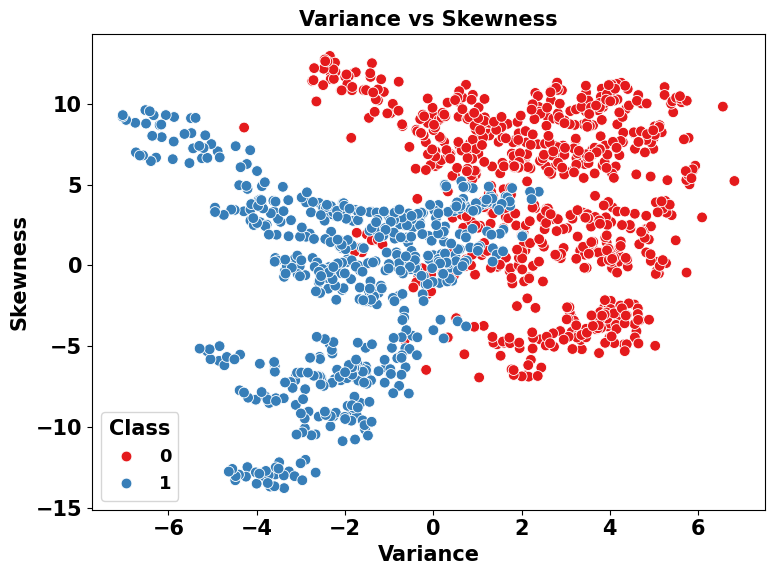

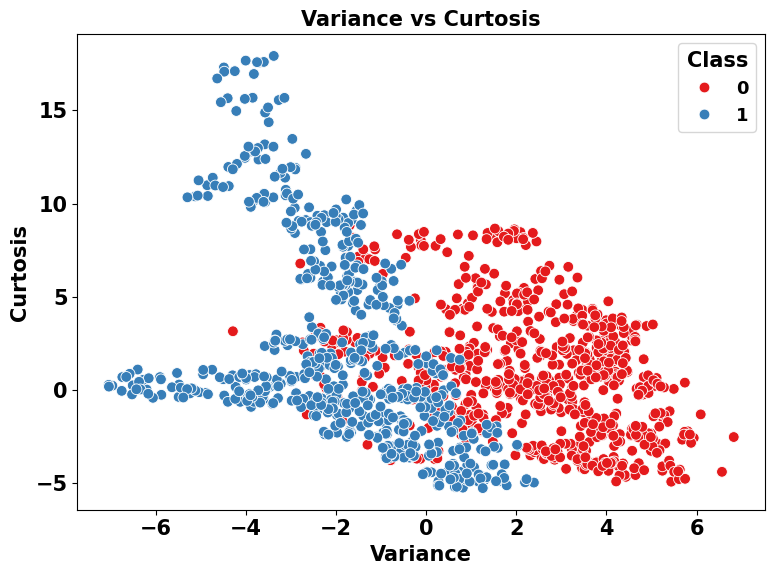

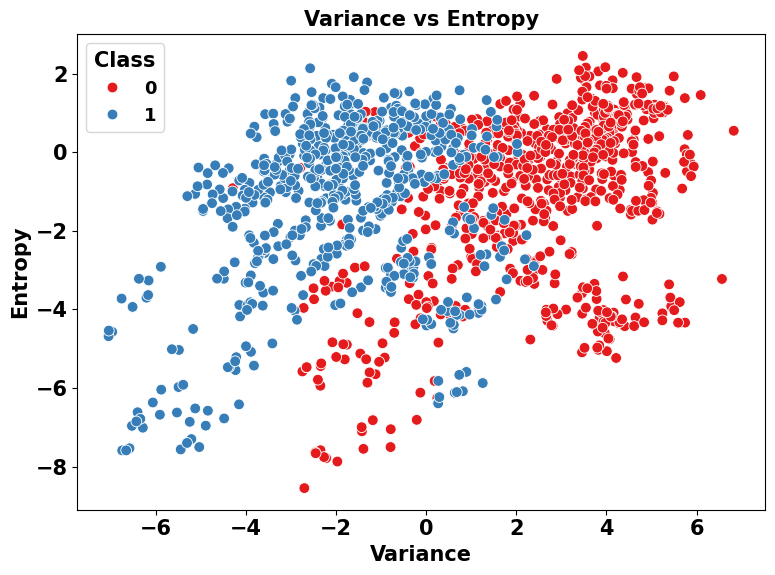

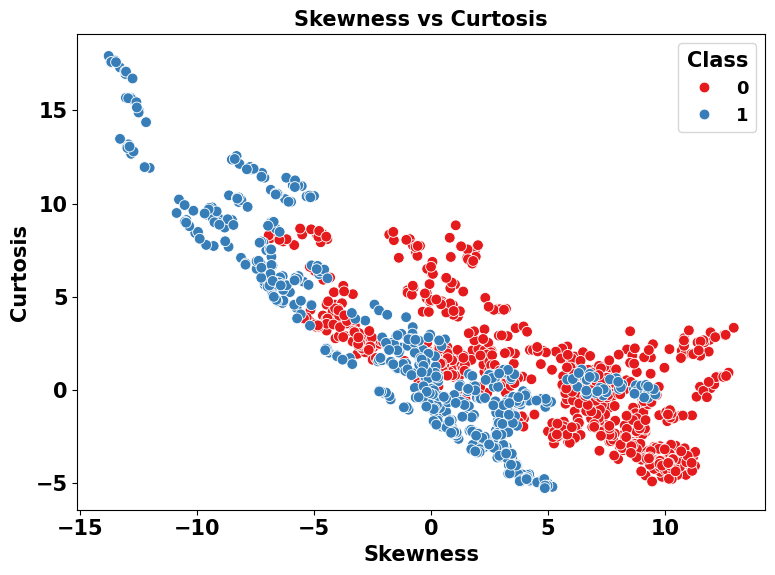

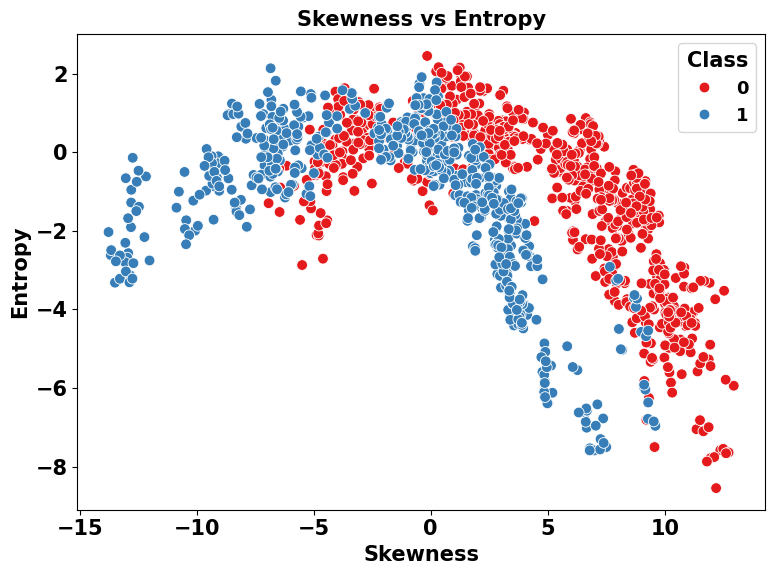

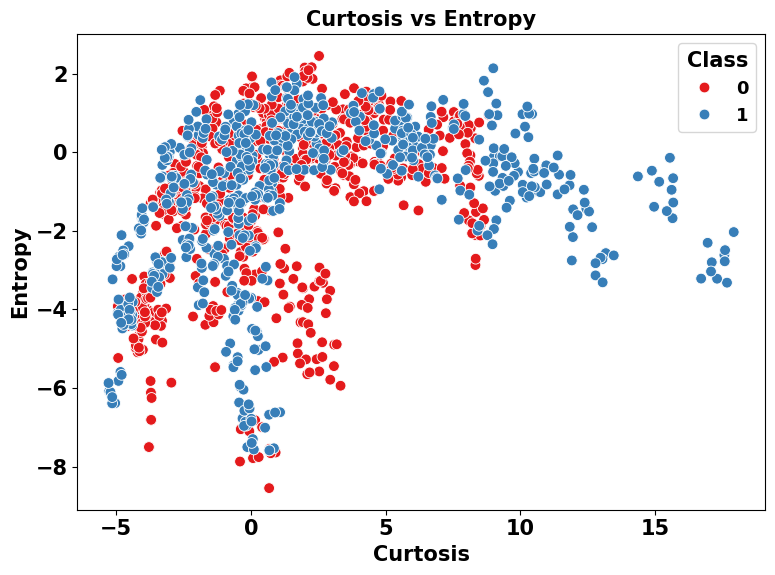

In [14]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

features = ["variance", "skewness", "curtosis", "entropy"]

for x, y in itertools.combinations(features, 2):

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="class",
        palette="Set1",
        s=60
    )

    plt.xlabel(x.capitalize(), fontsize=15, fontweight='bold')
    plt.ylabel(y.capitalize(), fontsize=15, fontweight='bold')
    plt.title(f"{x.capitalize()} vs {y.capitalize()}",
              fontsize=15,
              fontweight='bold')

    plt.legend(title="Class", fontsize=13, title_fontsize=15)

    plt.tight_layout()

    plt.savefig(f"{x}_vs_{y}.eps",
                format="eps",
                dpi=600,
                bbox_inches="tight")

    plt.show()

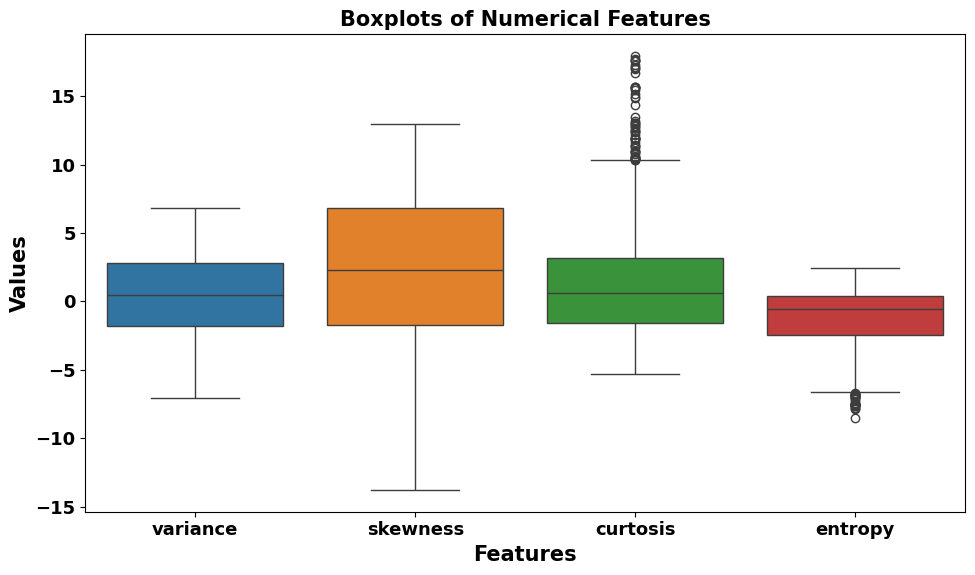

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["variance", "skewness", "curtosis", "entropy"]

plt.figure(figsize=(10,6))

sns.boxplot(data=df[features])

plt.xlabel("Features", fontsize=15, fontweight='bold')
plt.ylabel("Values", fontsize=15, fontweight='bold')
plt.title("Boxplots of Numerical Features", fontsize=15, fontweight='bold')

plt.xticks(fontsize=13, rotation=0)
plt.yticks(fontsize=13)

plt.tight_layout()

plt.savefig("Boxplots_All_Features.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop("class", axis=1)
y = df["class"]

# Train-Test Split (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [17]:
from sklearn.preprocessing import StandardScaler

# Normalize numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1097, 4)
Testing data shape: (275, 4)


In [18]:
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs

        # Store training history
        self.errors = []
        self.weight_history = []
        self.bias_history = []

    def initialize_parameters(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0

    def activation(self, x):
        if x >= 0:
            return 1
        return 0

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([self.activation(x) for x in linear_output])

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.initialize_parameters(n_features)
        for epoch in range(self.epochs):
            misclassified = 0
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = self.activation(linear_output)
                error = y[i] - prediction
                if error != 0:
                    misclassified += 1
                    # Update weights
                    self.weights += self.learning_rate * error * X[i]
                    # Update bias
                    self.bias += self.learning_rate * error
                # Save history
            self.errors.append(misclassified)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"\nEpoch {epoch + 1}")
            print(f"Misclassified Samples : {misclassified}")
            print(f"Weights : {self.weights}")
            print(f"Bias : {self.bias}")
            # Stop early if all samples are classified correctly
            if misclassified == 0:
                print("\nTraining converged.")
                break

In [19]:
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=100
)

perceptron.fit(X_train, y_train)


Epoch 1
Misclassified Samples : 51
Weights : [-0.06024909 -0.08407687 -0.06300015  0.00226864]
Bias : -0.03

Epoch 2
Misclassified Samples : 32
Weights : [-0.08625065 -0.10215292 -0.07663789  0.0073922 ]
Bias : -0.03

Epoch 3
Misclassified Samples : 27
Weights : [-0.09932445 -0.11330756 -0.08197553  0.00545098]
Bias : -0.04

Epoch 4
Misclassified Samples : 25
Weights : [-0.07988243 -0.11840653 -0.10632953 -0.00732292]
Bias : -0.05

Epoch 5
Misclassified Samples : 27
Weights : [-0.10986763 -0.1248832  -0.1030505  -0.00681503]
Bias : -0.04

Epoch 6
Misclassified Samples : 20
Weights : [-0.10451397 -0.12636185 -0.11458703  0.01092347]
Bias : -0.060000000000000005

Epoch 7
Misclassified Samples : 20
Weights : [-0.10701729 -0.14692623 -0.10333013  0.00774974]
Bias : -0.060000000000000005

Epoch 8
Misclassified Samples : 23
Weights : [-0.11516546 -0.14813196 -0.11435912 -0.00815023]
Bias : -0.05

Epoch 9
Misclassified Samples : 21
Weights : [-0.11519398 -0.13957003 -0.13408384 -0.00165482]


In [20]:
y_pred = perceptron.predict(X_test)

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9855
Precision: 0.9683
Recall   : 1.0000
F1-score : 0.9839


In [23]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[149   4]
 [  0 122]]


<Figure size 600x500 with 0 Axes>

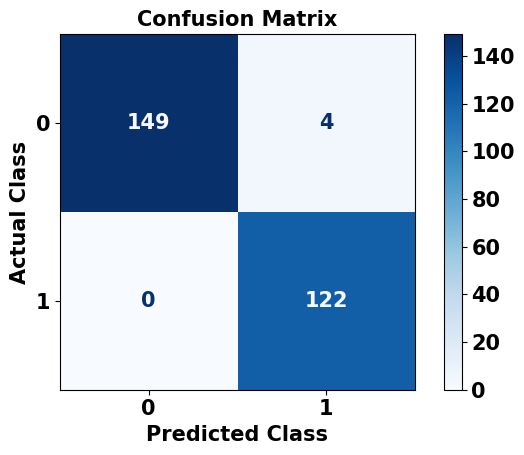

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")

plt.xlabel("Predicted Class", fontsize=15, fontweight="bold")
plt.ylabel("Actual Class", fontsize=15, fontweight="bold")
plt.title("Confusion Matrix", fontsize=15, fontweight="bold")

plt.tight_layout()

plt.savefig(
    "Confusion_Matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

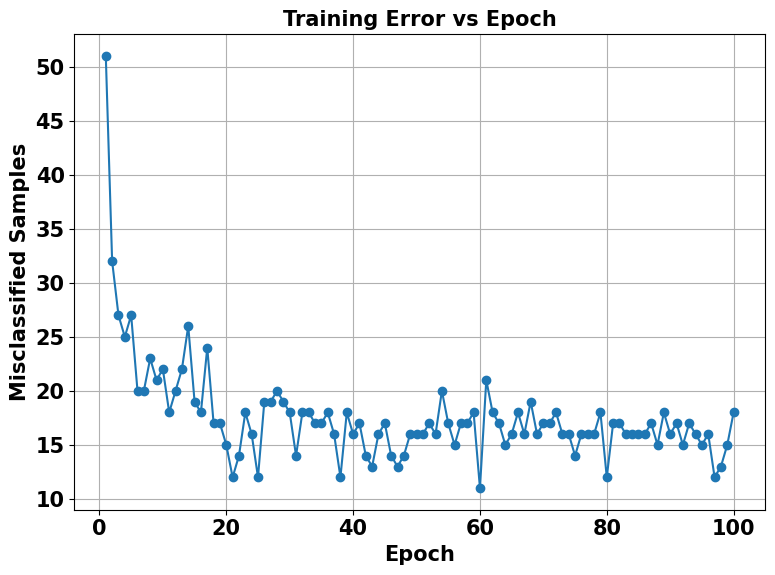

In [26]:
# Training Error vs Epoch
plt.figure(figsize=(8,6))

plt.plot(range(1, len(perceptron.errors)+1),
         perceptron.errors,
         marker='o')

plt.xlabel("Epoch", fontsize=15, fontweight='bold')
plt.ylabel("Misclassified Samples", fontsize=15, fontweight='bold')
plt.title("Training Error vs Epoch", fontsize=15, fontweight='bold')

plt.grid(True)

plt.tight_layout()

plt.savefig("Training_Error_vs_Epoch.eps",
            format='eps',
            dpi=600)

plt.show()

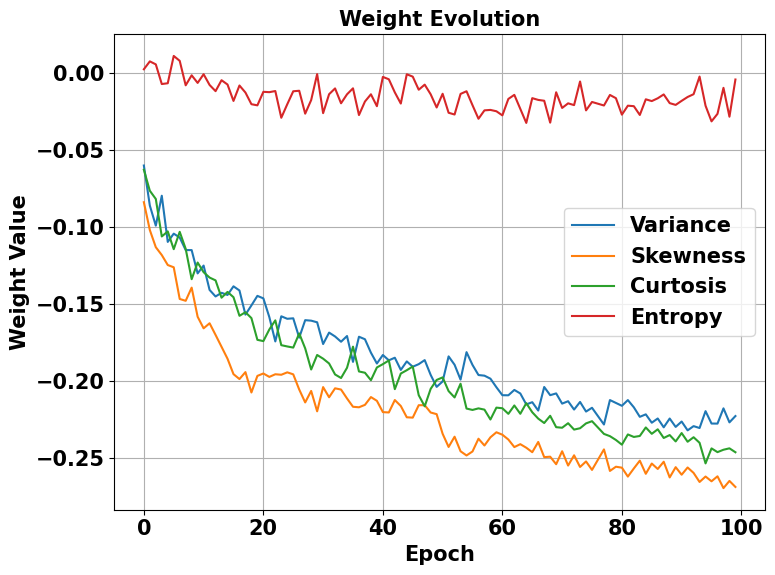

In [27]:
# Weightevolution
weights = np.array(perceptron.weight_history)

feature_names = ["Variance",
                 "Skewness",
                 "Curtosis",
                 "Entropy"]

plt.figure(figsize=(8,6))

for i in range(weights.shape[1]):
    plt.plot(weights[:,i], label=feature_names[i])

plt.xlabel("Epoch", fontsize=15, fontweight='bold')
plt.ylabel("Weight Value", fontsize=15, fontweight='bold')
plt.title("Weight Evolution", fontsize=15, fontweight='bold')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("Weight_Evolution.eps",
            format='eps',
            dpi=600)

plt.show()

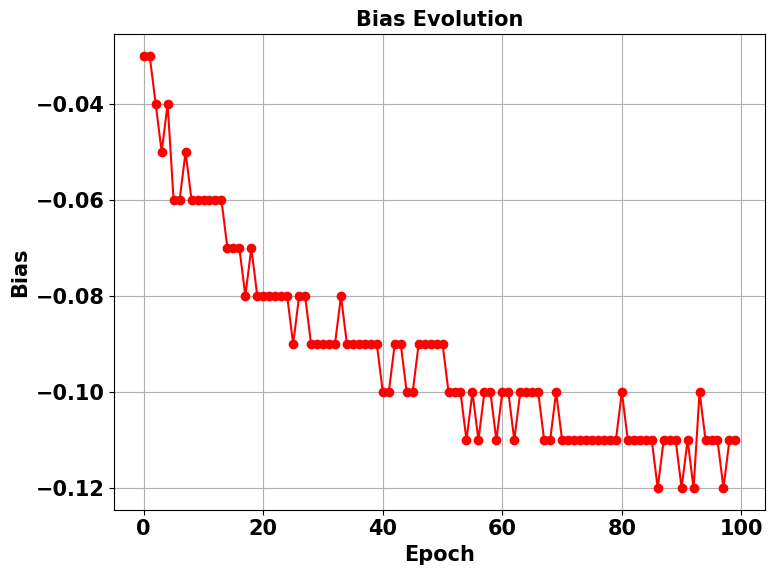

In [28]:
# bias evolution
plt.figure(figsize=(8,6))

plt.plot(perceptron.bias_history,
         marker='o',
         color='red')

plt.xlabel("Epoch", fontsize=15, fontweight='bold')
plt.ylabel("Bias", fontsize=15, fontweight='bold')
plt.title("Bias Evolution", fontsize=15, fontweight='bold')

plt.grid(True)

plt.tight_layout()

plt.savefig("Bias_Evolution.eps",
            format='eps',
            dpi=600)

plt.show()


Epoch 1
Misclassified Samples : 51
Weights : [-0.00602491 -0.00840769 -0.00630001  0.00022686]
Bias : -0.003

Epoch 2
Misclassified Samples : 32
Weights : [-0.00862507 -0.01021529 -0.00766379  0.00073922]
Bias : -0.003

Epoch 3
Misclassified Samples : 27
Weights : [-0.00993244 -0.01133076 -0.00819755  0.0005451 ]
Bias : -0.004

Epoch 4
Misclassified Samples : 25
Weights : [-0.00798824 -0.01184065 -0.01063295 -0.00073229]
Bias : -0.005

Epoch 5
Misclassified Samples : 27
Weights : [-0.01098676 -0.01248832 -0.01030505 -0.0006815 ]
Bias : -0.004

Epoch 6
Misclassified Samples : 20
Weights : [-0.0104514  -0.01263618 -0.0114587   0.00109235]
Bias : -0.006

Epoch 7
Misclassified Samples : 20
Weights : [-0.01070173 -0.01469262 -0.01033301  0.00077497]
Bias : -0.006

Epoch 8
Misclassified Samples : 23
Weights : [-0.01151655 -0.0148132  -0.01143591 -0.00081502]
Bias : -0.005

Epoch 9
Misclassified Samples : 21
Weights : [-0.0115194  -0.013957   -0.01340838 -0.00016548]
Bias : -0.006

Epoch 10


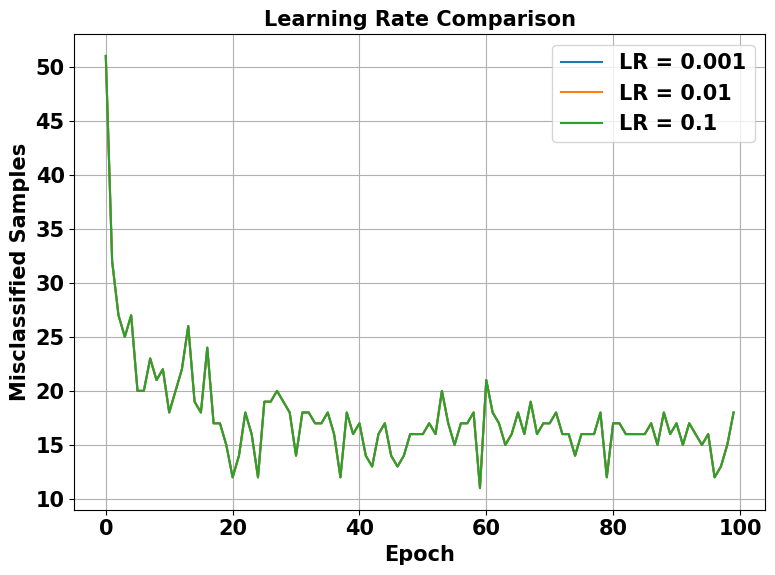

In [29]:
# learning rate comparison
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,6))

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=100
    )

    model.fit(X_train, y_train)

    plt.plot(model.errors,
             label=f"LR = {lr}")

plt.xlabel("Epoch", fontsize=15, fontweight='bold')
plt.ylabel("Misclassified Samples", fontsize=15, fontweight='bold')
plt.title("Learning Rate Comparison", fontsize=15, fontweight='bold')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("Learning_Rate_Comparison.eps",
            format='eps',
            dpi=600)

plt.show()

In [30]:
for lr in [0.001, 0.01, 0.1]:
    model = Perceptron(learning_rate=lr, epochs=20)
    model.fit(X_train, y_train)
    print(f"LR={lr}")
    print(model.errors)
    print()


Epoch 1
Misclassified Samples : 51
Weights : [-0.00602491 -0.00840769 -0.00630001  0.00022686]
Bias : -0.003

Epoch 2
Misclassified Samples : 32
Weights : [-0.00862507 -0.01021529 -0.00766379  0.00073922]
Bias : -0.003

Epoch 3
Misclassified Samples : 27
Weights : [-0.00993244 -0.01133076 -0.00819755  0.0005451 ]
Bias : -0.004

Epoch 4
Misclassified Samples : 25
Weights : [-0.00798824 -0.01184065 -0.01063295 -0.00073229]
Bias : -0.005

Epoch 5
Misclassified Samples : 27
Weights : [-0.01098676 -0.01248832 -0.01030505 -0.0006815 ]
Bias : -0.004

Epoch 6
Misclassified Samples : 20
Weights : [-0.0104514  -0.01263618 -0.0114587   0.00109235]
Bias : -0.006

Epoch 7
Misclassified Samples : 20
Weights : [-0.01070173 -0.01469262 -0.01033301  0.00077497]
Bias : -0.006

Epoch 8
Misclassified Samples : 23
Weights : [-0.01151655 -0.0148132  -0.01143591 -0.00081502]
Bias : -0.005

Epoch 9
Misclassified Samples : 21
Weights : [-0.0115194  -0.013957   -0.01340838 -0.00016548]
Bias : -0.006

Epoch 10
